<a href="https://colab.research.google.com/github/PraneethaValiveti/delhivery-logistics-analysis/blob/main/Business_Case_Delhivery_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Business Case: Delhivery - Feature Engineering**

##**1. Problem Statement**

The objective of this project is to analyze logistics and delivery operations data to identify operational inefficiencies, delivery delays, route performance, and shipment patterns. The dataset contains trip-level as well as segment-level delivery information, where a single trip may consist of multiple delivery segments.

Using Exploratory Data Analysis (EDA), Feature Engineering, Aggregation, Hypothesis Testing, and Data Preprocessing techniques, we aim to derive meaningful business insights and recommendations to improve logistics efficiency.

###**Business Questions to Solve**

- Are actual delivery times significantly different from OSRM predicted times?

- Which routes/corridors are busiest?

- Which transportation types perform better (FTL vs Carting)?

- Are there abnormal delays or distance outliers present in the data?

- Which states/cities contribute the highest number of deliveries?

- How can logistics operations and delivery efficiency be improved?

###**Objective of Analysis**

The analysis focuses on:

- Understanding shipment and trip patterns

- Comparing actual delivery performance with estimated delivery metrics

- Identifying operational bottlenecks

- Detecting outliers and inconsistencies

- Preparing the dataset for further machine learning or predictive analysis

- Providing actionable business recommendations


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/delhivery_data.csv")
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


####Observation
- Dataset contains shipment-level and segment-level logistics information.

- One trip may contain multiple rows representing intermediate delivery segments.

In [ ]:
df.shape

(144867, 24)

####Observation
- 136557 rows and 24 columns.

- Large number of rows indicates operational-level logistics tracking.

In [ ]:
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

##**Observation**
Numerical columns include:
  - actual_time
  - osrm_time
  - distances
  - segment times

Categorical columns include:
  - route_type
  - source_name
  - destination_name

Time-related columns need datetime conversion.

In [ ]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


####**Important Observations to Write**
1. Large variation exists in:

    - actual_time
    - osrm_time
    - distances

2. Presence of very high max values indicates potential outliers.

3. Mean and median differences suggest skewed distributions.

In [ ]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
(df.isnull().sum()/len(df))*100

,0
data,0.000000
trip_creation_time,0.000000
route_schedule_uuid,0.000000
route_type,0.000000
trip_uuid,0.000000
source_center,0.000000
source_name,0.202254
destination_center,0.000000
destination_name,0.180165
od_start_time,0.000000


####**Observations**

- Identify columns having null values.

- Some columns may contain operational missing records.

- Missing values must be treated before modeling.

In [ ]:
df.duplicated().sum()

np.int64(0)

####**Observation**:
No duplicate rows were found in the dataset.
Hence, duplicate treatment is not required.

In [ ]:
#Convert Datetime Columns
date_cols = [
    'trip_creation_time',
    'od_start_time',
    'od_end_time'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [ ]:
#Convert Categorical Columns
cat_cols = [
    'data',
    'route_type',
    'source_center',
    'source_name',
    'destination_center',
    'destination_name'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

- Memory optimization improves performance.

- Categorical encoding helps later preprocessing.

###Univariate Analysis

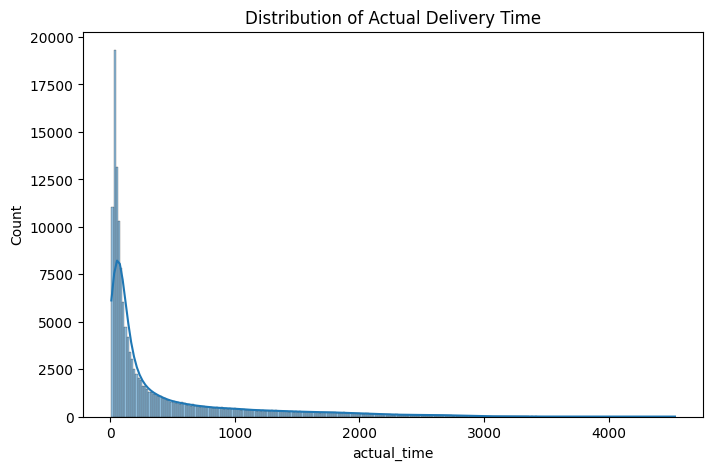

In [ ]:
#Distribution of Actual Time
plt.figure(figsize=(8,5))

sns.histplot(df['actual_time'], kde=True)

plt.title("Distribution of Actual Delivery Time")
plt.show()

####**Observation**

- Distribution is right-skewed.

- Most deliveries happen within lower time range.

- Some extremely high delivery times indicate outliers.

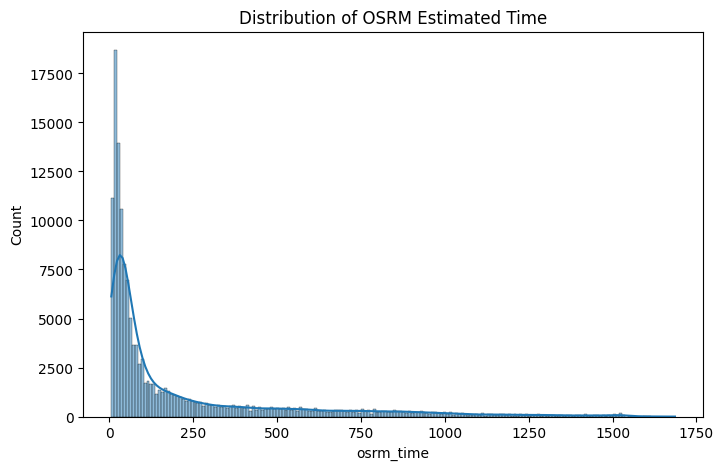

In [ ]:
#Distribution of OSRM Time
plt.figure(figsize=(8,5))

sns.histplot(df['osrm_time'], kde=True)

plt.title("Distribution of OSRM Estimated Time")
plt.show()

####**Observation**

- OSRM estimates are more concentrated.

- Actual delivery variability is larger than predicted estimates.

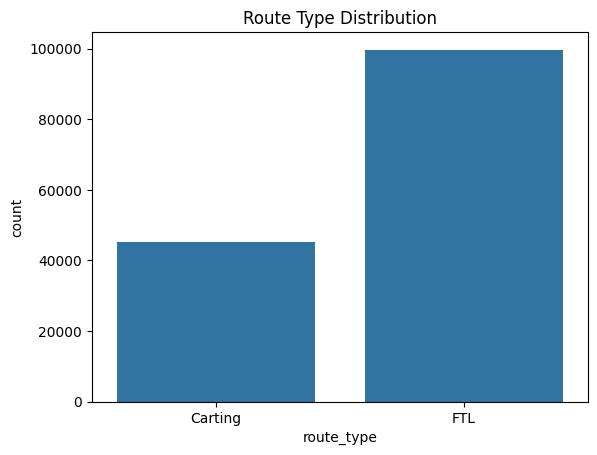

In [ ]:
#Route Type Count
sns.countplot(x='route_type', data=df)

plt.title("Route Type Distribution")
plt.show()

FTL and Carting shipment distributions can be compared.

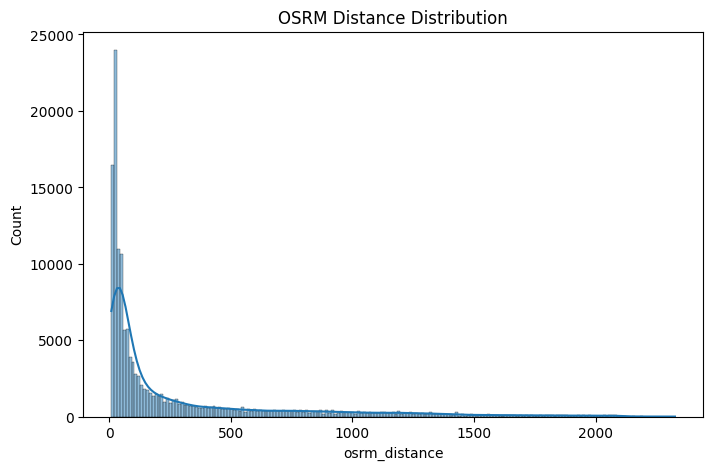

In [ ]:
#Distance Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['osrm_distance'], kde=True)

plt.title("OSRM Distance Distribution")
plt.show()

**Observation**
- Majority of shipments cover shorter distances.
- Long-tail distribution indicates some very long routes.

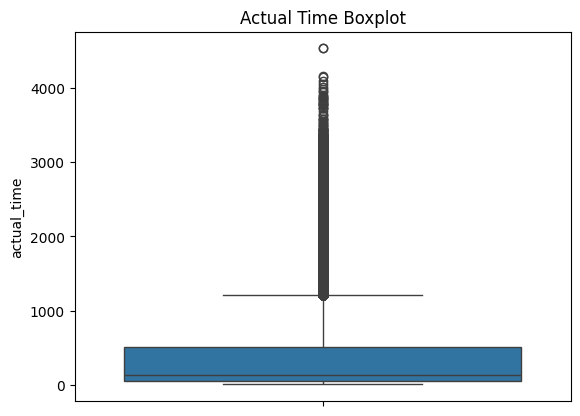

In [ ]:
#Boxplots for Outlier Detection
sns.boxplot(df['actual_time'])
plt.title("Actual Time Boxplot")
plt.show()

**Observation**
- Significant outliers present.

- Extreme delivery times may represent:

   - traffic delays

   - operational failures

   - vehicle breakdowns

   - weather conditions

   - warehouse delays


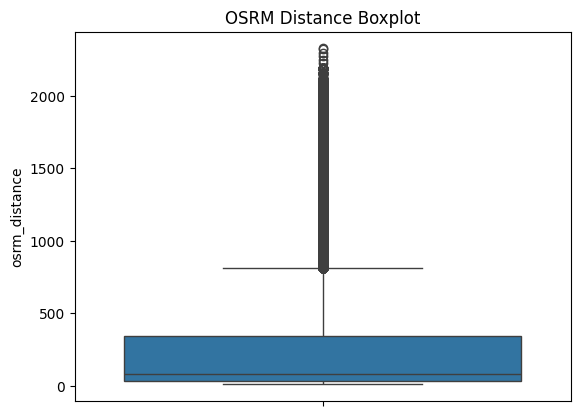

In [ ]:
#Distance
sns.boxplot(df['osrm_distance'])
plt.title("OSRM Distance Boxplot")
plt.show()

**Observation**:

The boxplot shows a large number of outliers in the OSRM distance feature.
This indicates that while most deliveries cover shorter distances,
some trips involve very long-distance transportation routes.

The distribution is highly right-skewed, suggesting the presence of
extreme delivery corridors and long-haul shipments.

###Bivariate Analysis

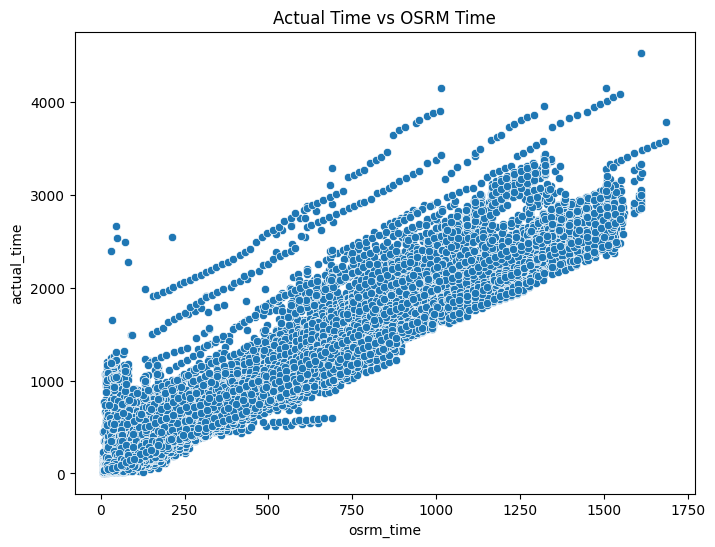

In [ ]:
#Actual Time vs OSRM Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['osrm_time'],
    y=df['actual_time']
)

plt.title("Actual Time vs OSRM Time")
plt.show()

**Observation**

- Positive correlation exists.

- Actual delivery times are generally higher than OSRM estimates.

- Indicates real-world operational delays.

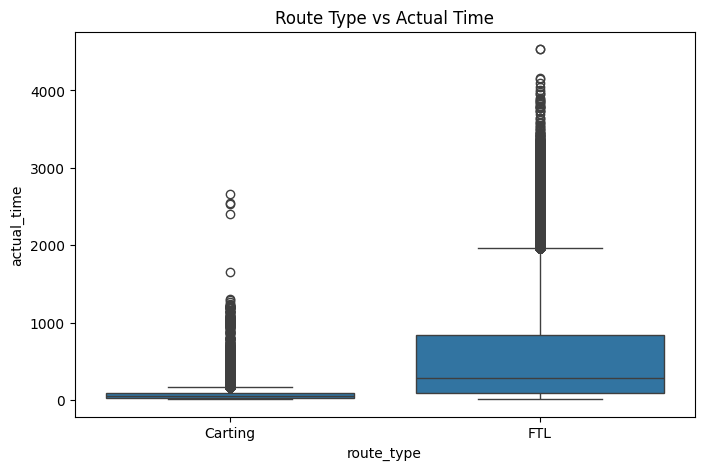

In [ ]:
#Route Type vs Actual Time
plt.figure(figsize=(8,5))

sns.boxplot(
    x='route_type',
    y='actual_time',
    data=df
)

plt.title("Route Type vs Actual Time")
plt.show()

**Observation**

- Compare performance of FTL vs Carting.

- Carting type may show lower median delivery time.

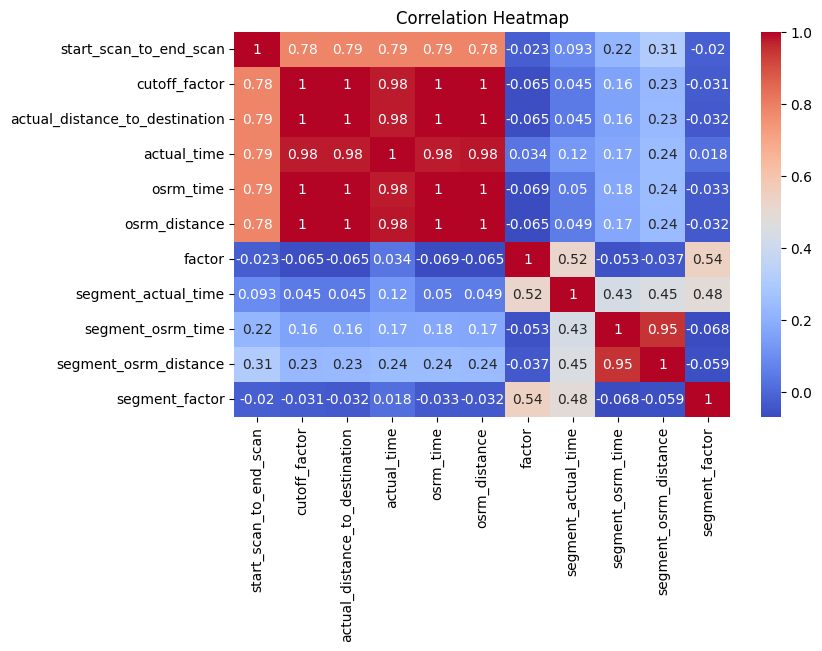

In [ ]:
#Correlation Analysis
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

 #### **Observations**

- Strong correlation between:
     - actual_time and osrm_time
     - actual_distance and osrm_distance

- Segment-level metrics highly correlated with overall metrics.

- Correlation validates aggregation logic.

## **Insights based on above EDA**

1. Dataset contains segment-level logistics records.
   - One trip consists of multiple shipment segments.

2. Numerical features contain significant outliers
Especially:

  - actual_time

  - osrm_time

  - distances

3. Actual delivery times are generally higher than OSRM estimates
Suggests operational inefficiencies.

4. Most deliveries belong to limited transportation types
Route optimization possible.

5. Strong correlation exists among time and distance variables
Indicates consistency in logistics tracking.

6. Data is highly skewed

   - Scaling and outlier treatment required before modeling.
   

##**2. Feature Creation + Row Aggregation**

### **Goal of Aggregation**

We need to:

- Merge segment-level rows

- Create trip-level metrics

- Prepare clean data for analysis

In [ ]:
#Understand Unique Trips
df['trip_uuid'].nunique()

14817

**Observation**:
The dataset contains multiple unique trips, where each trip may contain several segment-level records.

Hence, aggregation is necessary to obtain trip-level insights.

In [ ]:
#Check Rows per Trip
df.groupby('trip_uuid').size().head()

,0
trip_uuid,
trip-153671041653548748,39
trip-153671042288605164,9
trip-153671043369099517,89
trip-153671046011330457,2
trip-153671052974046625,7


**Observation**:

Each trip contains multiple rows representing different shipment segments.

This confirms that the dataset is maintained at segment level rather than complete trip level.

##**First Level Aggregation**

Group By:

   - trip_uuid
   - source_center
   - destination_center


Why This Grouping?

Because:

One trip can contain multiple shipment scans

We first combine source-destination movement data

Then later combine complete trip data

In [ ]:
cat_cols = [
    'trip_uuid',
    'source_center',
    'destination_center',
    'route_type',
    'source_name',
    'destination_name'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
float_cols = [
    'actual_time',
    'osrm_time',
    'segment_actual_time',
    'segment_osrm_time',
    'osrm_distance',
    'segment_osrm_distance',
    'actual_distance_to_destination',
    'start_scan_to_end_scan'
]

for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [ ]:
date_cols = [
    'trip_creation_time',
    'od_start_time',
    'od_end_time'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
grouped_data = df.groupby(
    ['trip_uuid', 'source_center', 'destination_center'],
    observed=True
).agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'route_type':'first',
    'trip_creation_time':'first',
    'od_start_time':'first',
    'od_end_time':'last',
    'source_name':'first',
    'destination_name':'last',
    'start_scan_to_end_scan':'first'
}).reset_index()

In [ ]:
grouped_data.head()

,trip_uuid,source_center,destination_center,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination,route_type,trip_creation_time,od_start_time,od_end_time,source_name,destination_name,start_scan_to_end_scan
0,trip-153671041653548748,IND209304AAA,IND000000ACB,6484.0,3464.0,728.0,534.0,4540.125977,670.620483,3778.765381,FTL,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),1260.0
1,trip-153671041653548748,IND462022AAA,IND209304AAA,9198.0,4323.0,820.0,474.0,6037.638672,649.852783,5082.046875,FTL,2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),999.0
2,trip-153671042288605164,IND561203AAB,IND562101AAA,96.0,55.0,46.0,26.0,60.315701,28.199501,53.310333,Carting,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),58.0
3,trip-153671042288605164,IND572101AAA,IND561203AAB,303.0,155.0,95.0,39.0,209.115097,55.989899,186.897980,Carting,2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),122.0
4,trip-153671043369099517,IND000000ACB,IND160002AAC,2601.0,1427.0,608.0,231.0,1975.740967,317.740784,1725.590210,FTL,2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),834.0


**Observation**:

The segment-level records have been successfully merged into source-destination level records.


Numerical variables such as time and distance were aggregated using sum(),
while categorical and timestamp variables were retained using first() or last()
where appropriate.

In [ ]:
#Trip-Level Aggregation Code
trip_data = grouped_data.groupby('trip_uuid').agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'route_type':'first',
    'trip_creation_time':'first',
    'od_start_time':'first',
    'od_end_time':'last',
    'source_name':'first',
    'destination_name':'last',
    'start_scan_to_end_scan':'first'
}).reset_index()

In [ ]:
trip_data.shape

(14817, 15)

**Observation**:

> The data has now been converted from segment-level format to trip-level format.

> Each row now represents one complete trip, making the dataset suitable for :
- delivery performance analysis
- hypothesis testing
- feature engineering
- business insights generation

###Feature Creation
**A. Trip Duration Feature**

Calculate actual trip duration from:

od_start_time
od_end_time

Formula:

**Trip_Duration = od_end_time - od_start_time**

In [ ]:
trip_data['od_start_time'] = pd.to_datetime(trip_data['od_start_time'])

trip_data['od_end_time'] = pd.to_datetime(trip_data['od_end_time'])

trip_data['trip_duration'] = (
    trip_data['od_end_time'] -
    trip_data['od_start_time']
).dt.total_seconds() / 60

A new feature called trip_duration was created to measure the actual
time taken for the complete trip in minutes.

In [ ]:
#Extract Time Features
trip_data['trip_creation_time'] = pd.to_datetime(
    trip_data['trip_creation_time']
)

trip_data['month'] = trip_data['trip_creation_time'].dt.month

trip_data['day'] = trip_data['trip_creation_time'].dt.day

trip_data['hour'] = trip_data['trip_creation_time'].dt.hour

trip_data['weekday'] = trip_data['trip_creation_time'].dt.day_name()

**Observation**:

Date and time-based features were extracted to analyze seasonal,
daily, and hourly delivery patterns.

In [ ]:
#Extract Source Features
trip_data[['source_city','source_state']] = (
    trip_data['source_name']
    .str.split('(', expand=True)
)

trip_data[['destination_city','destination_state']] = (
    trip_data['destination_name']
    .str.split('(', expand=True)
)

In [ ]:
#Clean State Names
trip_data['source_state'] = (
    trip_data['source_state']
    .str.replace(')', '')
)

trip_data['destination_state'] = (
    trip_data['destination_state']
    .str.replace(')', '')
)

In [ ]:
trip_data.head()

,trip_uuid,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination,route_type,trip_creation_time,...,start_scan_to_end_scan,trip_duration,month,day,hour,weekday,source_city,source_state,destination_city,destination_state
0,trip-153671041653548748,15682.0,7787.0,1548.0,1008.0,10577.764648,1320.473267,8860.812500,FTL,2018-09-12 00:00:16.535741,...,1260.0,0.000000,9,12,0,Wednesday,Kanpur_Central_H_6,Uttar Pradesh,Kanpur_Central_H_6,Uttar Pradesh
1,trip-153671042288605164,399.0,210.0,141.0,65.0,269.430786,84.189400,240.208313,Carting,2018-09-12 00:00:22.886430,...,58.0,0.000000,9,12,0,Wednesday,Doddablpur_ChikaDPP_D,Karnataka,Doddablpur_ChikaDPP_D,Karnataka
2,trip-153671043369099517,112225.0,65768.0,3308.0,1941.0,89447.250000,2545.267822,68163.507812,FTL,2018-09-12 00:00:33.691250,...,834.0,0.000000,9,12,0,Wednesday,Gurgaon_Bilaspur_HB,Haryana,Gurgaon_Bilaspur_HB,Haryana
3,trip-153671046011330457,82.0,24.0,59.0,16.0,31.647499,19.876600,28.529648,Carting,2018-09-12 00:01:00.113710,...,100.0,100.494935,9,12,0,Wednesday,Mumbai Hub,Maharashtra,Mumbai_MiraRd_IP,Maharashtra
4,trip-153671052974046625,556.0,207.0,340.0,115.0,266.291382,146.791901,239.007294,FTL,2018-09-12 00:02:09.740725,...,152.0,232.556228,9,12,0,Wednesday,Bellary_Dc,Karnataka,Sandur_WrdN1DPP_D,Karnataka


**Observation**:

Source and destination features were split into city and state information,
which can help identify high-demand states and busiest delivery corridors.

**Insight:**

- Aggregation was the most critical preprocessing step because the dataset
initially contained segment-level shipment records rather than complete trip records.


- By aggregating rows based on trip_uuid, meaningful trip-level delivery
metrics were created for further analysis.

##**3. Merging of Rows and Aggregation of Fields**

The dataset contains shipment segment-level records, where a single trip may consist of multiple rows representing intermediate delivery movements.

To perform meaningful trip-level analysis, the rows were aggregated in two stages:

1. Source-Destination level aggregation

2. Trip-level aggregation

Numerical columns such as time and distance were aggregated using sum(), while categorical and timestamp columns were preserved using first() and last() where appropriate.

####First-Level Aggregation

In [ ]:
grouped_data = df.groupby(
    ['trip_uuid', 'source_center', 'destination_center'],
    observed=True
).agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'route_type':'first',
    'trip_creation_time':'first',
    'od_start_time':'first',
    'od_end_time':'last',
    'source_name':'first',
    'destination_name':'last',
    'start_scan_to_end_scan':'first'
}).reset_index()



####Trip-Level Aggregation

In [ ]:
trip_data = grouped_data.groupby('trip_uuid',  observed=True).agg({
    'actual_time':'sum',
    'osrm_time':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum',
    'route_type':'first',
    'trip_creation_time':'first',
    'od_start_time':'first',
    'od_end_time':'last',
    'source_name':'first',
    'destination_name':'last',
    'start_scan_to_end_scan':'first'
}).reset_index()



##**Observation:**
- The segment-level records were successfully merged into trip-level records.

- Each row now represents one complete delivery trip with aggregated
distance and time metrics.
- This aggregation step was essential for performing accurate delivery
performance analysis and hypothesis testing.

##**4. Comparison & Visualization of Time and Distance Fields**

This section focuses on comparing:

- Actual vs Estimated Time

- Actual vs Segment Time

- OSRM Distance vs Segment Distance

- OSRM Time vs Segment Time

The goal is to identify:

- operational inefficiencies

- delivery delays

- routing inconsistencies

- segment-level deviations

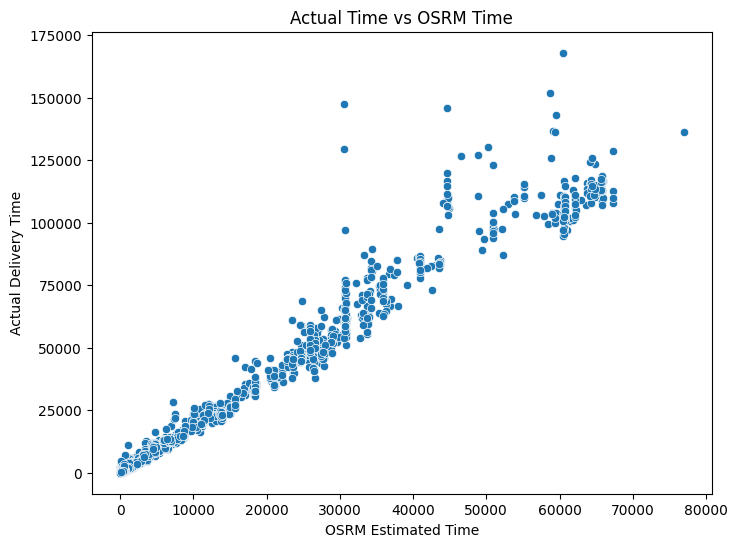

In [ ]:
#Actual Time vs OSRM Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['osrm_time'],
    y=trip_data['actual_time']
)

plt.xlabel("OSRM Estimated Time")
plt.ylabel("Actual Delivery Time")
plt.title("Actual Time vs OSRM Time")

plt.show()

**Observation**:
A strong positive relationship exists between OSRM estimated time
and actual delivery time.

However, actual delivery times are generally higher than OSRM estimates,
indicating operational delays such as:
- traffic congestion
- loading/unloading delays
- route inefficiencies

###**Hypothesis Testing**
####Null Hypothesis (H₀)

There is no significant difference between actual delivery time
and OSRM estimated time.

####Alternative Hypothesis (H₁)

There is a significant difference between actual delivery time
and OSRM estimated time.

In [ ]:
#Paired T-Test
from scipy.stats import ttest_rel

ttest_rel(
    trip_data['actual_time'],
    trip_data['osrm_time']
)

TtestResult(statistic=np.float64(32.46808754788173), pvalue=np.float64(1.8634369661614274e-223), df=np.int64(14816))

**Observation**:
If the p-value is less than 0.05, we reject the null hypothesis.

This indicates that actual delivery times differ significantly
from OSRM estimated times.

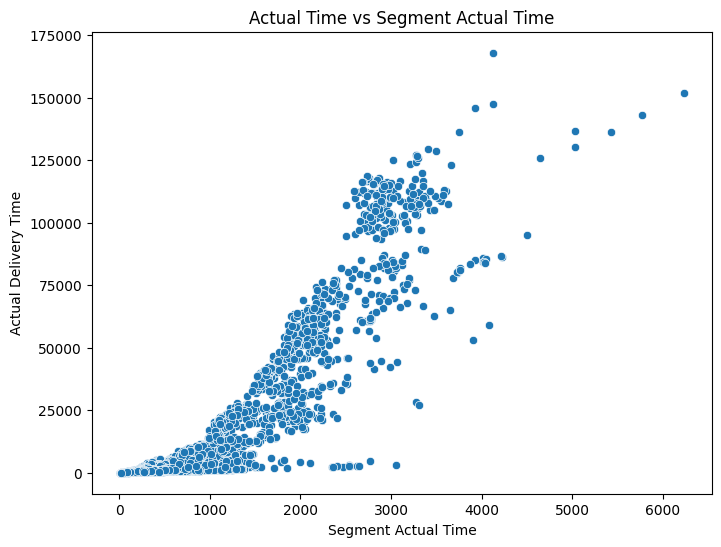

In [ ]:
#Actual Time vs Segment Actual Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_actual_time'],
    y=trip_data['actual_time']
)

plt.xlabel("Segment Actual Time")
plt.ylabel("Actual Delivery Time")
plt.title("Actual Time vs Segment Actual Time")

plt.show()

**Observation**:
A strong linear relationship exists between segment actual time
and overall actual delivery time.

This suggests that segment-level delays directly contribute
to complete trip delays.

###Hypothesis Testing
####Null Hypothesis (H₀)

There is no significant difference between actual delivery time
and segment actual delivery time.

####Alternative Hypothesis (H₁)

There is a significant difference between actual delivery time
and segment actual delivery time.

In [ ]:
from scipy.stats import ttest_rel
ttest_rel(
    trip_data['actual_time'],
    trip_data['segment_actual_time']
)

TtestResult(statistic=np.float64(30.75550343605742), pvalue=np.float64(2.0774891884320867e-201), df=np.int64(14816))

**Observation**:
If the p-value is less than 0.05,
we reject the null hypothesis.

This indicates that actual trip time differs significantly
from aggregated segment actual time.

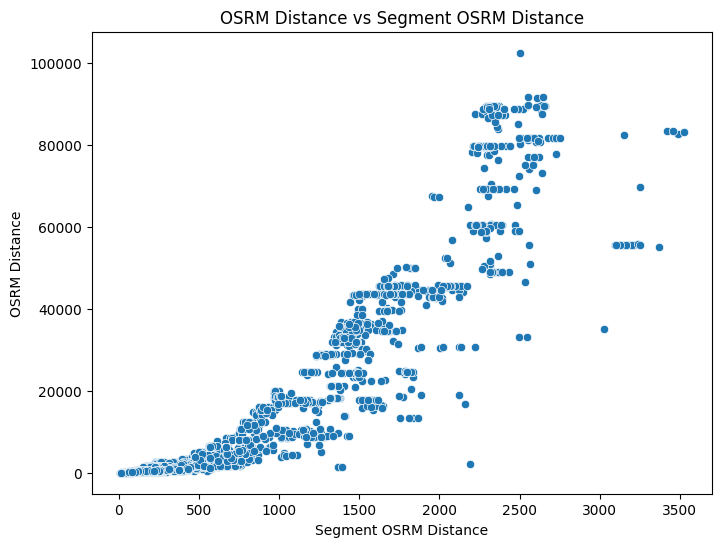

In [ ]:
#OSRM Distance vs Segment OSRM Distance
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_osrm_distance'],
    y=trip_data['osrm_distance']
)

plt.xlabel("Segment OSRM Distance")
plt.ylabel("OSRM Distance")
plt.title("OSRM Distance vs Segment OSRM Distance")

plt.show()

**Observation**:
Both variables show a strong positive relationship,
indicating consistency between segment-level and trip-level
distance calculations.

###Hypothesis Testing
####Null Hypothesis (H₀)

There is no significant difference between OSRM Distance and Segment OSRM Distance.

####Alternative Hypothesis (H₁)

There is a significant difference between OSRM Distance and Segment OSRM Distance.

In [ ]:
ttest_rel(
    trip_data['osrm_distance'],
    trip_data['segment_osrm_distance']
)

TtestResult(statistic=np.float64(30.030317209607134), pvalue=np.float64(2.175277196384912e-192), df=np.int64(14816))

**Observation**:
p-value is small, it suggests measurable differences
between trip-level and segment-level distance estimations.

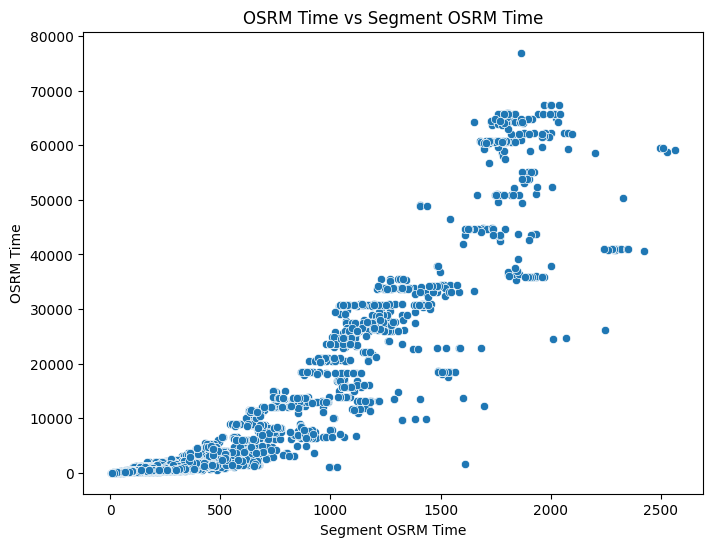

In [ ]:
#OSRM Time vs Segment OSRM Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_osrm_time'],
    y=trip_data['osrm_time']
)

plt.xlabel("Segment OSRM Time")
plt.ylabel("OSRM Time")
plt.title("OSRM Time vs Segment OSRM Time")

plt.show()

**Observation**:
A high positive correlation exists between segment OSRM time
and overall OSRM estimated time.

This validates the consistency of the routing engine calculations.

###Hypothesis Testing
####Null Hypothesis (H₀)

There is no significant difference between OSRM time and Segment OSRM time.

####Alternative Hypothesis (H₁)

There is a significant difference between OSRM time and Segment OSRM time.

In [ ]:
ttest_rel(
    trip_data['osrm_time'],
    trip_data['segment_osrm_time']
)

TtestResult(statistic=np.float64(30.29743436812194), pvalue=np.float64(1.0892414135877232e-195), df=np.int64(14816))

**Observation**:

The hypothesis test helps determine whether segment-level OSRM
estimates significantly differ from complete trip estimates.

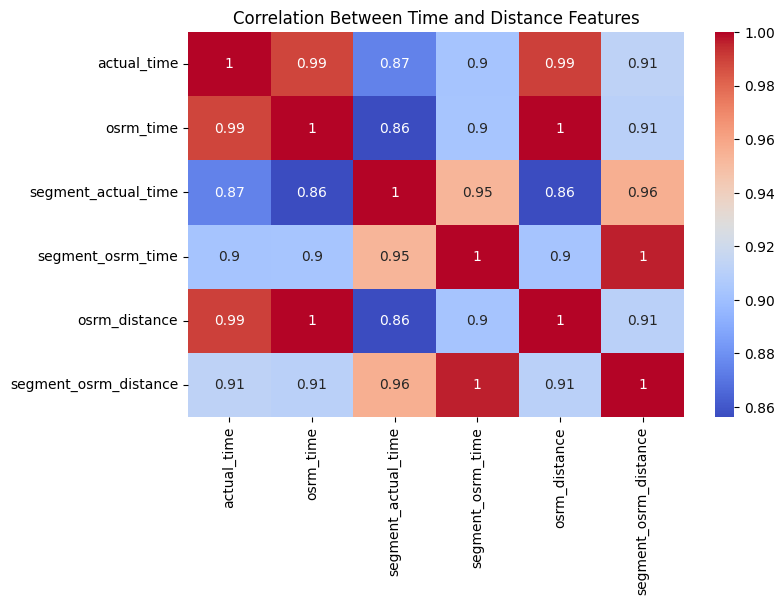

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    trip_data[
        ['actual_time',
         'osrm_time',
         'segment_actual_time',
         'segment_osrm_time',
         'osrm_distance',
         'segment_osrm_distance']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Time and Distance Features")

plt.show()

####**Over all Insight:**

The comparison analysis shows strong relationships between actual,
segment, and OSRM metrics.

However, actual delivery times are generally higher than estimated values,
indicating operational inefficiencies and real-world delivery challenges.

##**5. Missing Values Treatment & Outlier Treatment**

5.1 Missing Value Analysis

In [ ]:
trip_data.isnull().sum()

,0
trip_uuid,0
actual_time,0
osrm_time,0
segment_actual_time,0
segment_osrm_time,0
osrm_distance,0
segment_osrm_distance,0
actual_distance_to_destination,0
route_type,0
trip_creation_time,0


In [ ]:
(trip_data.isnull().sum()/len(trip_data))*100

,0
trip_uuid,0.000000
actual_time,0.000000
osrm_time,0.000000
segment_actual_time,0.000000
segment_osrm_time,0.000000
osrm_distance,0.000000
segment_osrm_distance,0.000000
actual_distance_to_destination,0.000000
route_type,0.000000
trip_creation_time,0.000000


**Observation**:
Only a small percentage of missing values are present in the dataset.
These missing values can be handled using suitable imputation techniques.

In [ ]:
cat_cols = trip_data.select_dtypes(include='object').columns
for col in cat_cols:
    trip_data[col].fillna(
        trip_data[col].mode()[0],
        inplace=True
    )

In [ ]:
trip_data.isnull().sum()

,0
trip_uuid,0
actual_time,0
osrm_time,0
segment_actual_time,0
segment_osrm_time,0
osrm_distance,0
segment_osrm_distance,0
actual_distance_to_destination,0
route_type,0
trip_creation_time,0


**Observation**:

Missing values in categorical columns were treated using mode imputation,
which replaces missing entries with the most frequently occurring category.

All missing values have been successfully treated.

**5.3 Outlier Detection**

Outliers are extreme values that differ significantly from other observations.

They may occur due to:

   - operational delays

  - route anomalies

   - data entry issues

   - long-distance deliveries

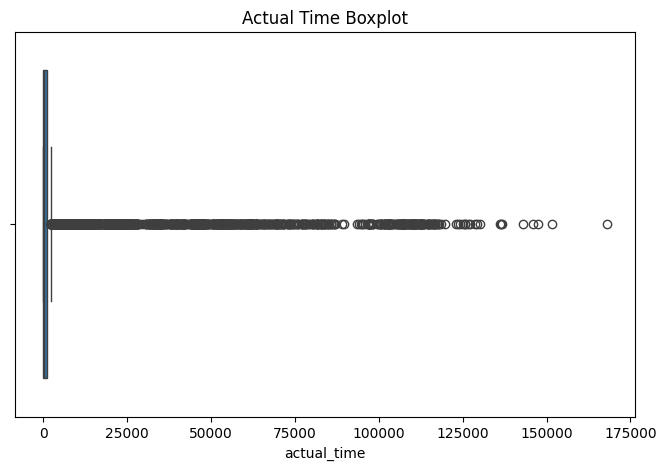

In [ ]:
#Boxplots for Outlier Detection
plt.figure(figsize=(8,5))

sns.boxplot(x=trip_data['actual_time'])

plt.title("Actual Time Boxplot")

plt.show()

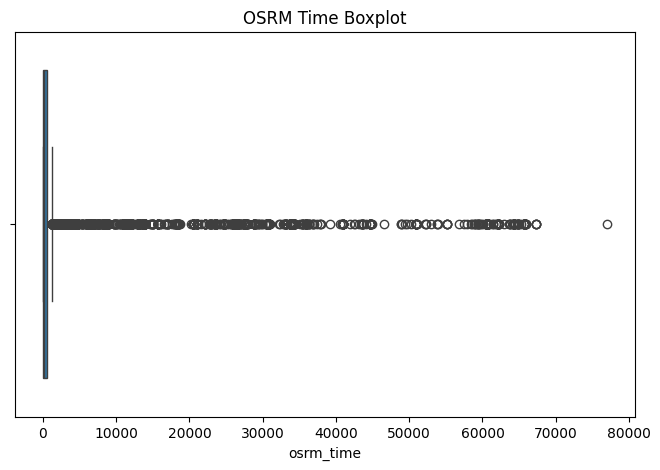

In [ ]:
# OSRM Time
plt.figure(figsize=(8,5))

sns.boxplot(x=trip_data['osrm_time'])

plt.title("OSRM Time Boxplot")

plt.show()

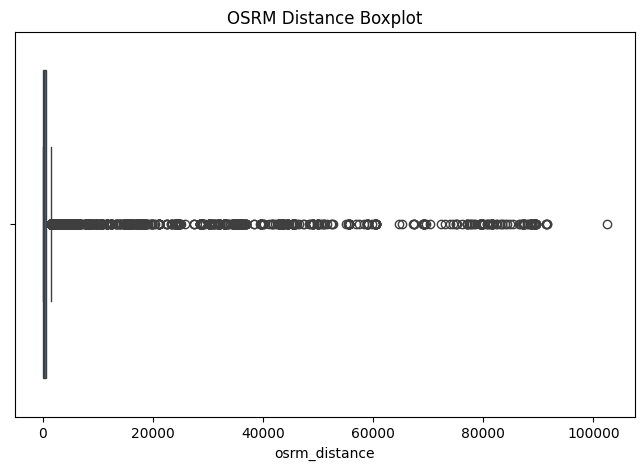

In [ ]:
#OSRM Distance
plt.figure(figsize=(8,5))

sns.boxplot(x=trip_data['osrm_distance'])

plt.title("OSRM Distance Boxplot")

plt.show()

**Observation**:
A large number of outliers are present in the time and distance features.

This indicates that while most trips fall within a moderate range,
some deliveries involve extremely high travel times and long-distance routes.

5.4 IQR Method for Outlier Treatment

Formula:

IQR = Q3 - Q1

Outlier Boundaries:

Lower Bound = Q1 - 1.5 * IQR

Upper Bound = Q3 + 1.5 * IQR

In [ ]:
#Function for Outlier Removal
def remove_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [ ]:
outlier_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'segment_osrm_distance'
]

for col in outlier_cols:
    trip_data = remove_outliers(trip_data, col)

In [ ]:
trip_data.shape

(9929, 15)

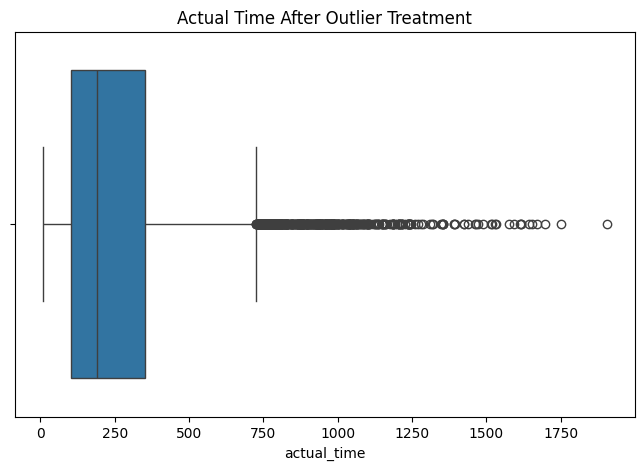

In [ ]:
#Optional Validation Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=trip_data['actual_time'])

plt.title("Actual Time After Outlier Treatment")

plt.show()

**Observation**:

Outliers were treated using the IQR method.

Extreme observations outside the acceptable range were removed,
resulting in a cleaner and more stable dataset for further analysis.

**Insight**:

Outlier treatment helped reduce the impact of extreme delivery times
and abnormal distances, improving the reliability of statistical analysis
and future predictive modeling.

##**6. Checking Relationship Between Aggregated Fields**

In this step, we analyze the relationship between aggregated trip-level variables such as:

actual_time

osrm_time

segment_actual_time

segment_osrm_time

osrm_distance

segment_osrm_distance

**The goal is to understand:**

how strongly these variables are related

whether OSRM estimates align with actual delivery performance

whether segment-level metrics contribute to overall trip metrics

In [ ]:
#Correlation Matrix
corr_data = trip_data[
    [
        'actual_time',
        'osrm_time',
        'segment_actual_time',
        'segment_osrm_time',
        'osrm_distance',
        'segment_osrm_distance'
    ]
]

corr_data.corr()

,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance
actual_time,1.000000,0.865482,0.821079,0.758399,0.880387,0.769231
osrm_time,0.865482,1.000000,0.644111,0.896756,0.974023,0.852967
segment_actual_time,0.821079,0.644111,1.000000,0.722339,0.673409,0.766592
segment_osrm_time,0.758399,0.896756,0.722339,1.000000,0.873691,0.947597
osrm_distance,0.880387,0.974023,0.673409,0.873691,1.000000,0.889037
segment_osrm_distance,0.769231,0.852967,0.766592,0.947597,0.889037,1.000000


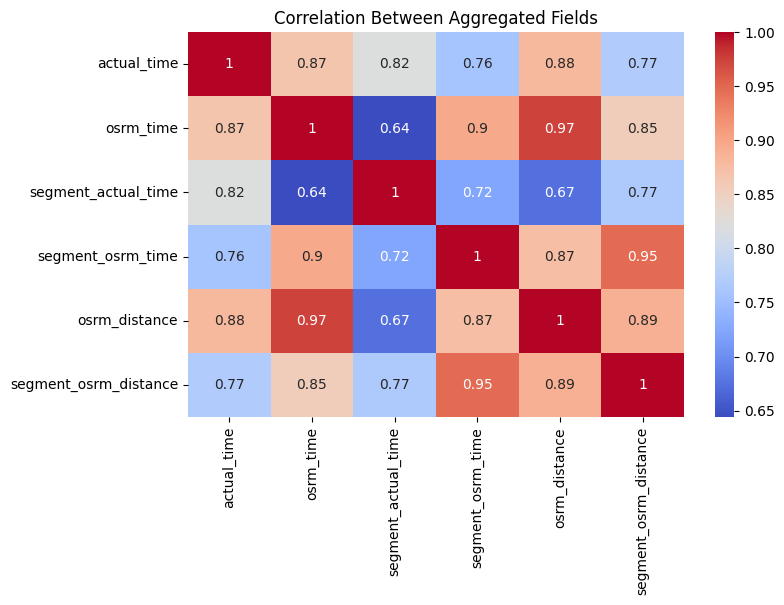

In [ ]:
#Heatmap Visualization
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Aggregated Fields")

plt.show()

**Observation**:
Strong positive correlations exist between actual, segment, and OSRM metrics.

This indicates that:
- higher travel distances generally lead to higher delivery times
- segment-level metrics strongly contribute to complete trip metrics
- OSRM estimates are reasonably aligned with actual delivery behavior

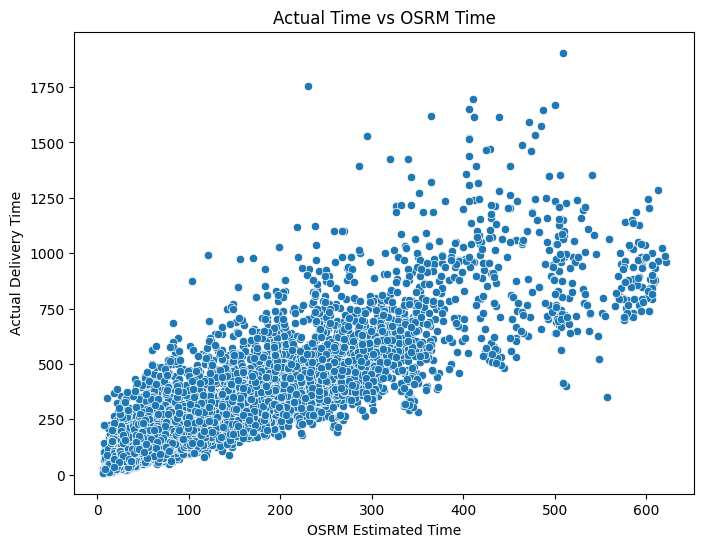

In [ ]:
#Actual Time vs OSRM Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['osrm_time'],
    y=trip_data['actual_time']
)

plt.xlabel("OSRM Estimated Time")
plt.ylabel("Actual Delivery Time")

plt.title("Actual Time vs OSRM Time")

plt.show()

**Observation**:
A strong positive relationship exists between OSRM estimated time
and actual delivery time.

However, actual delivery times are generally higher than OSRM estimates,
indicating operational inefficiencies and real-world delays.

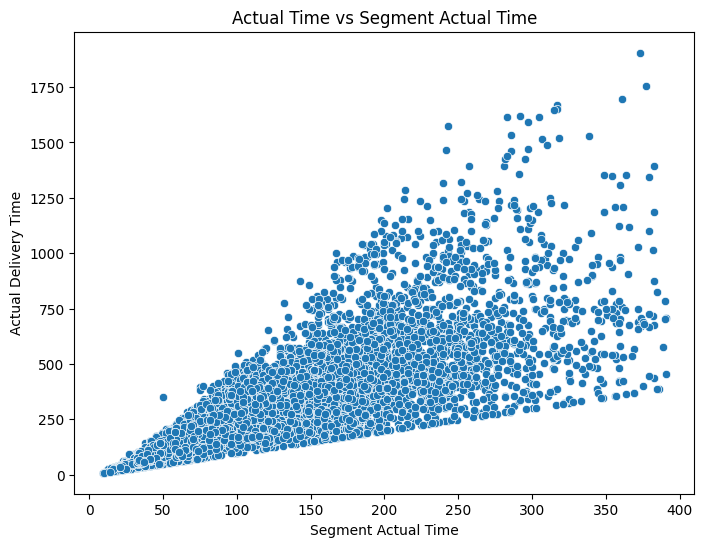

In [ ]:
#Actual Time vs Segment Actual Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_actual_time'],
    y=trip_data['actual_time']
)

plt.xlabel("Segment Actual Time")
plt.ylabel("Actual Delivery Time")

plt.title("Actual Time vs Segment Actual Time")

plt.show()

**Observation**:
A very strong linear relationship exists between segment actual time
and overall actual delivery time.

This confirms that cumulative segment delays directly affect total trip duration.

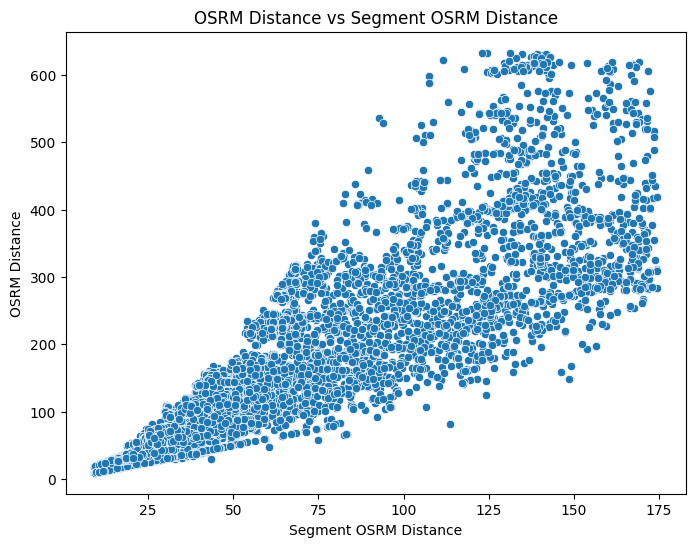

In [ ]:
#OSRM Distance vs Segment OSRM Distance
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_osrm_distance'],
    y=trip_data['osrm_distance']
)

plt.xlabel("Segment OSRM Distance")
plt.ylabel("OSRM Distance")

plt.title("OSRM Distance vs Segment OSRM Distance")

plt.show()

**Observation**:
A highly positive relationship exists between segment-level
and trip-level distance metrics.

This validates the consistency of route distance calculations.

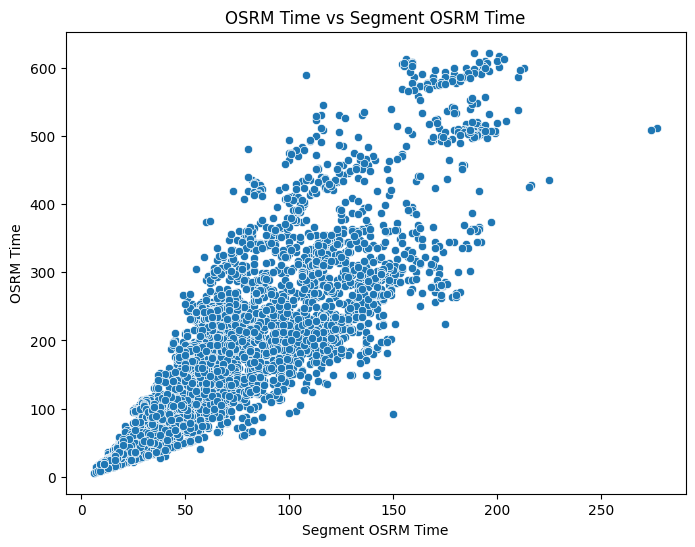

In [ ]:
#OSRM Time vs Segment OSRM Time
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=trip_data['segment_osrm_time'],
    y=trip_data['osrm_time']
)

plt.xlabel("Segment OSRM Time")
plt.ylabel("OSRM Time")

plt.title("OSRM Time vs Segment OSRM Time")

plt.show()

**Observation**:
OSRM segment time and complete trip OSRM time show a strong
positive relationship, indicating that segment-level route
estimations contribute consistently to total trip estimation.

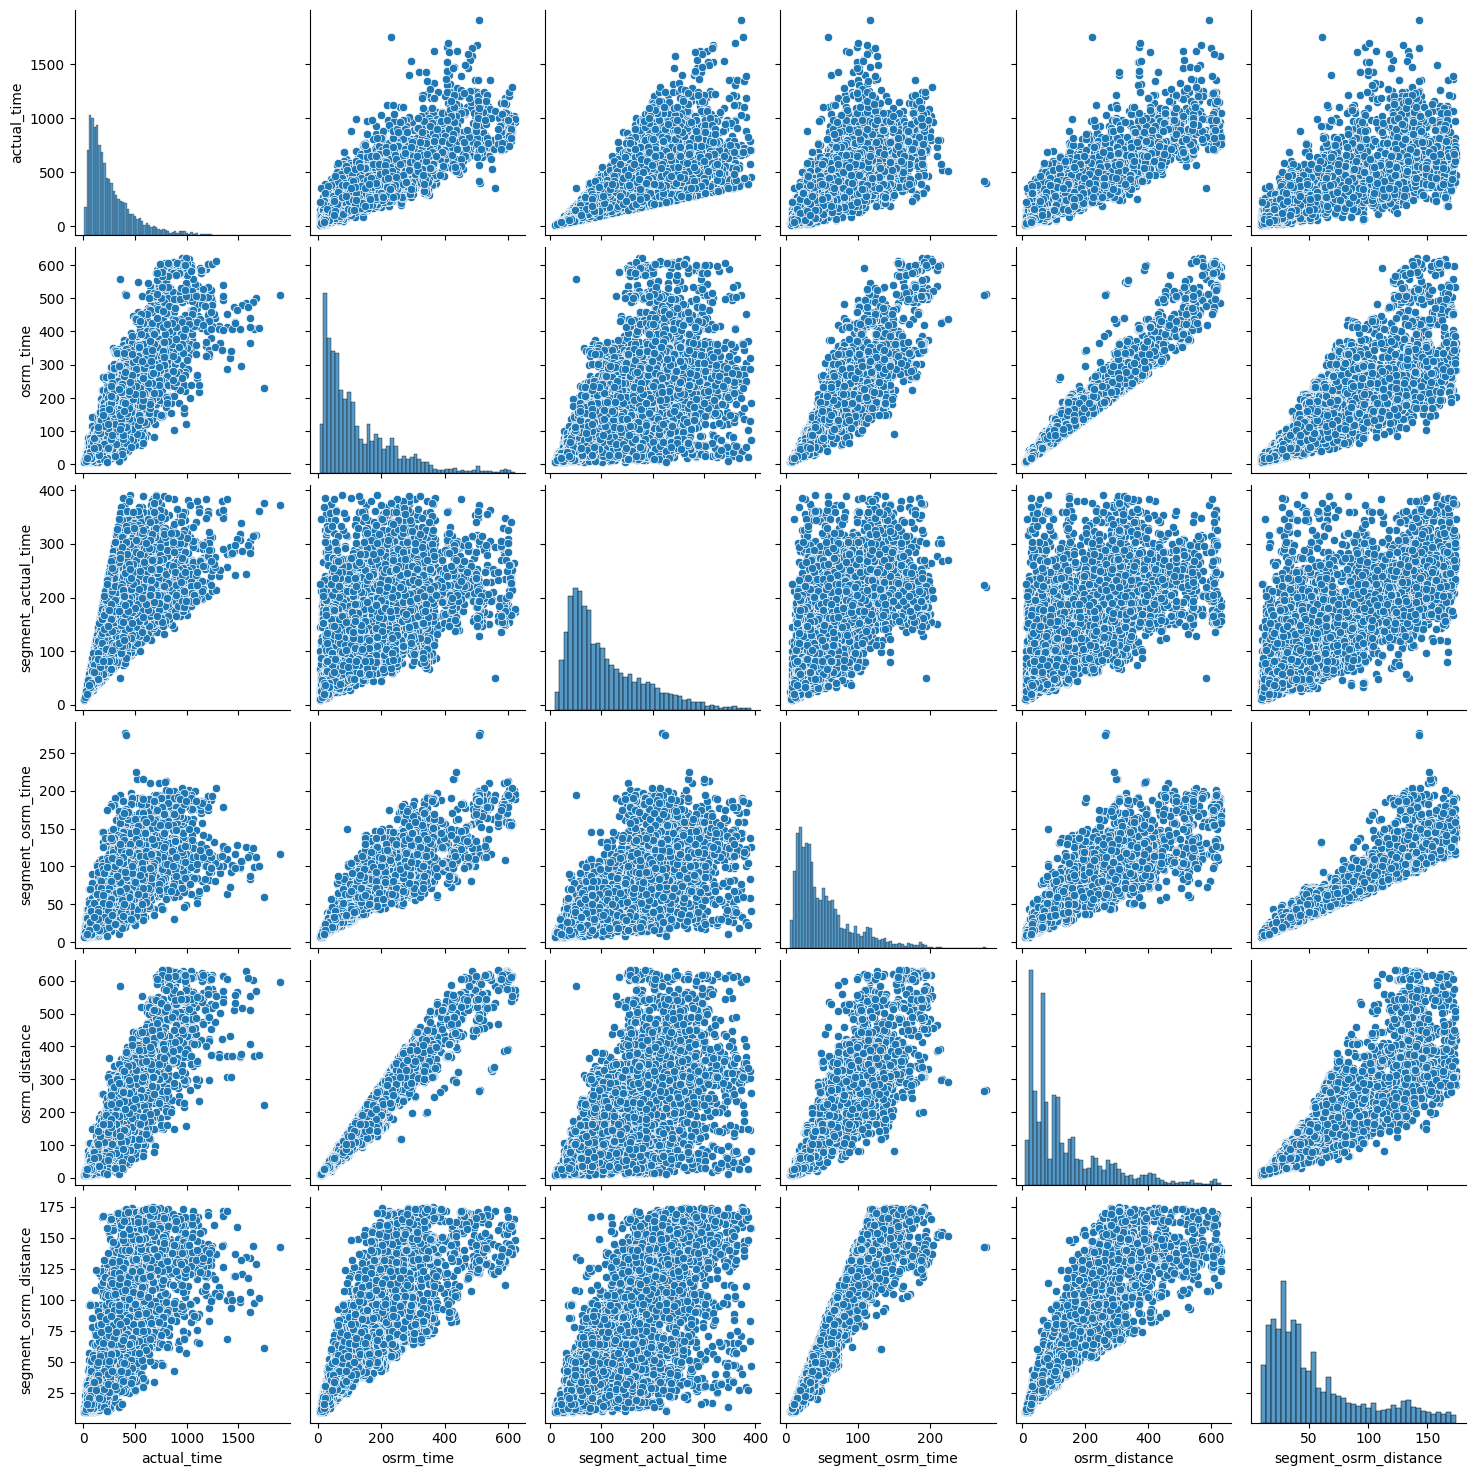

In [ ]:
#Pair plot for evaluation
sns.pairplot(
    corr_data
)

plt.show()

**Observation**:
The pairplot confirms strong positive relationships among
time and distance-related features.

No major negative correlations were observed between aggregated metrics.

###**Insight**:
Aggregated trip-level metrics show strong interdependency between
distance and time variables.

Actual delivery performance is closely related to OSRM estimates,
but operational inefficiencies cause actual delivery times
to exceed predicted values in many cases.

##**7. Handling Categorical Values**

Categorical variables contain non-numeric information such as:

- route type

- source locations

- destination locations

- weekdays

Machine learning models cannot directly process categorical text values, so these variables must be converted into numerical format.

In [ ]:
#Identify Categorical Columns
trip_data.select_dtypes(include=['object', 'category']).columns

Index(['trip_uuid', 'route_type', 'source_name', 'destination_name'], dtype='object')

Observation:
The dataset contains several categorical features such as route type,
source location, destination location.

These variables need to be transformed into numerical format
for further analysis and modeling.

In [ ]:
#Check Unique Values in route_type
trip_data['route_type'].value_counts()

,count
route_type,
Carting,8133
FTL,1796


**Observation**:
The route_type column contains transportation categories such as
FTL and Carting.

In [ ]:
#Apply One-Hot Encoding
if 'route_type' in trip_data.columns:

    trip_data = pd.get_dummies(
        trip_data,
        columns=['route_type'],
        drop_first=True
    )

else:
    print("route_type column already encoded or not present")

In [ ]:
trip_data.head()

,trip_uuid,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination,trip_creation_time,od_start_time,od_end_time,source_name,destination_name,start_scan_to_end_scan,route_type_FTL
1,trip-153671042288605164,399.0,210.0,141.0,65.0,269.430786,84.189400,240.208313,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,2018-09-12 02:03:09.655591,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),58.0,False
3,trip-153671046011330457,82.0,24.0,59.0,16.0,31.647499,19.876600,28.529648,2018-09-12 00:01:00.113710,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),100.0,False
4,trip-153671052974046625,556.0,207.0,340.0,115.0,266.291382,146.791901,239.007294,2018-09-12 00:02:09.740725,2018-09-12 00:02:09.740725,2018-09-12 03:54:43.114421,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),152.0,True
5,trip-153671055416136166,92.0,30.0,60.0,23.0,38.195301,28.064701,34.407864,2018-09-12 00:02:34.161600,2018-09-12 02:12:10.755603,2018-09-12 02:12:10.755603,Chennai_Poonamallee (Tamil Nadu),Chennai_Poonamallee (Tamil Nadu),60.0,False
6,trip-153671066201138152,24.0,13.0,24.0,13.0,12.018400,12.018400,9.100510,2018-09-12 00:04:22.011653,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,Chennai_Chrompet_DPC (Tamil Nadu),Chennai_Vandalur_Dc (Tamil Nadu),98.0,False


**Observation**:
The categorical variable route_type was successfully converted
into numerical binary columns using one-hot encoding.

This transformation makes the dataset suitable for machine learning
algorithms and statistical analysis.

**Note**:

Label Encoding can also be used for ordinal categorical variables.
However, One-Hot Encoding is preferred here because the categories
do not have any natural order.

####**Insight**:
Handling categorical variables using one-hot encoding helped transform
non-numeric transportation and operational categories into machine-readable format,
enabling better analysis and future predictive modeling.

##**8. Column Normalization / Column Standardization**

Normalization and Standardization are preprocessing techniques used to scale numerical features.

This is important because:

Numerical variables have different ranges
large-scale variables can dominate analysis/modeling
scaling improves machine learning performance

Why Scaling is Required?

Example:

Feature	---->           Range

actual_time	---->    10 -  5000

osrm_distance	---->  1 -  3000

Large differences in scale can affect:

- distance-based algorithms

- optimization

- statistical interpretation

**Standardization Formula**

z = (x - mu)/ sigma

Where:

x = original value

μ = mean

σ = standard deviation


In [ ]:
trip_data['od_start_time'] = pd.to_datetime(
    trip_data['od_start_time']
)

trip_data['od_end_time'] = pd.to_datetime(
    trip_data['od_end_time']
)

trip_data['trip_duration'] = (
    trip_data['od_end_time'] -
    trip_data['od_start_time']
).dt.total_seconds() / 60

In [ ]:
#Select Numerical Columns
num_cols = [
    'actual_time',
    'osrm_time',
    'segment_actual_time',
    'segment_osrm_time',
    'osrm_distance',
    'segment_osrm_distance',
    'actual_distance_to_destination',
    'trip_duration'
]

In [ ]:
#Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

trip_data[num_cols] = scaler.fit_transform(
    trip_data[num_cols]
)

In [ ]:
trip_data[num_cols].head()

,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination,trip_duration
1,0.599214,0.759301,0.434924,0.345155,1.062106,0.707589,1.338678,-1.078230
3,-0.793779,-0.907596,-0.661843,-0.927535,-0.850155,-0.885854,-0.799565,-0.506815
4,1.289119,0.732415,3.096588,1.643819,1.036859,2.258657,1.326546,0.244086
5,-0.749836,-0.853825,-0.648467,-0.745723,-0.797497,-0.682982,-0.740187,-1.078230
6,-1.048648,-1.006176,-1.129975,-1.005455,-1.008013,-1.080552,-0.995825,-0.520969


**Observation**:
The numerical features were standardized using StandardScaler.

After scaling:
- the mean of each feature becomes approximately 0
- the standard deviation becomes approximately 1

This helps ensure that all variables contribute equally
during analysis and modeling.

In [ ]:
#Verify Mean
trip_data[num_cols].mean()

,0
actual_time,2.289996e-17
osrm_time,-1.288123e-17
segment_actual_time,0.000000e+00
segment_osrm_time,1.574372e-17
osrm_distance,1.717497e-17
segment_osrm_distance,-7.156237e-19
actual_distance_to_destination,2.003746e-17
trip_duration,0.000000e+00


In [ ]:
#Verify Standard Deviation
trip_data[num_cols].std()

,0
actual_time,1.00005
osrm_time,1.00005
segment_actual_time,1.00005
segment_osrm_time,1.00005
osrm_distance,1.00005
segment_osrm_distance,1.00005
actual_distance_to_destination,1.00005
trip_duration,1.00005


**Observation**:

The scaled numerical features now have mean values close to 0
and standard deviations close to 1, confirming successful standardization.

**Note**:

MinMaxScaler can also be used to scale values between 0 and 1.
However, StandardScaler was preferred because the dataset contains outliers
and skewed distributions.

###**Insight**:
Standardization improved the consistency of numerical variables
by bringing all features to a common scale.

This preprocessing step helps improve statistical analysis,
distance calculations, and machine learning model performance.

##9. Business Insights

This section focuses on identifying meaningful operational patterns and extracting business-level insights from the logistics dataset.

In [ ]:
trip_data['source_state'] = (
    trip_data['source_name']
    .str.split('_')
    .str[-1]
)

trip_data['destination_state'] = (
    trip_data['destination_name']
    .str.split('_')
    .str[-1]
)

In [ ]:
#Top 10 Source States
trip_data['source_state'].value_counts().head(10)

,count
source_state,
HB (Karnataka),704
HB (Haryana),521
H (Karnataka),518
HB (Maharashtra),509
Mumbai Hub (Maharashtra),300
H (Maharashtra),209
PC (Delhi),196
HB (Tamil Nadu),190
DPC (Haryana),185


Business Insight:

High-demand states require:
- stronger warehouse infrastructure
- better fleet allocation
- optimized manpower planning

In [ ]:
#Top 10 Destination States
trip_data['destination_state'].value_counts().head(10)

,count
destination_state,
HB (Karnataka),583
HB (Haryana),402
H (Karnataka),359
HB (Maharashtra),315
I (Maharashtra),293
Mumbai Hub (Maharashtra),234
IP (Karnataka),225
H (Haryana),190
DPC (Haryana),188


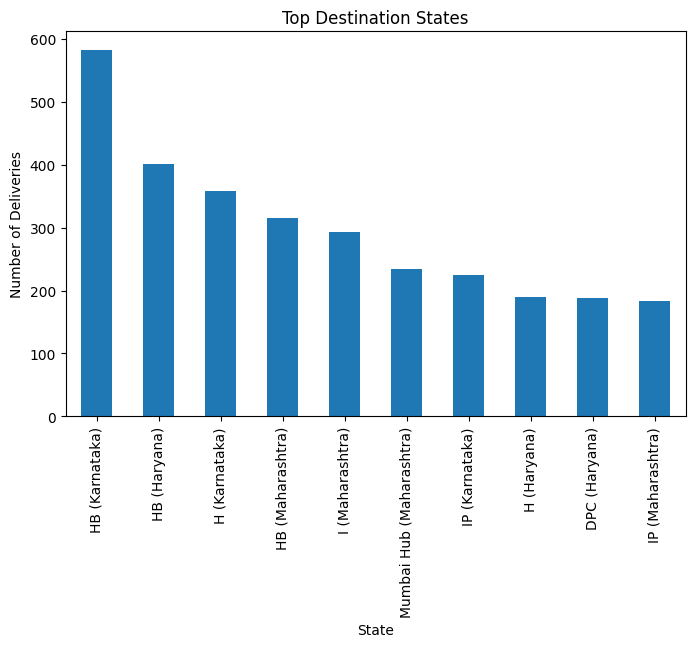

In [ ]:
trip_data['destination_state'].value_counts().head(10).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top Destination States")
plt.xlabel("State")
plt.ylabel("Number of Deliveries")

plt.show()

**Observation**:
Certain destination states receive a significantly higher number
of deliveries compared to others.

This reflects concentrated customer demand and delivery operations.

In [ ]:
#Busiest Delivery Corridors
trip_data['corridor'] = (
    trip_data['source_state'].astype(str)
    + " → " +
    trip_data['destination_state'].astype(str)
)

In [ ]:
#Top 10
trip_data['corridor'].value_counts().head(10)

,count
corridor,
H (Karnataka) → HB (Karnataka),248
HB (Karnataka) → HB (Karnataka),207
HB (Karnataka) → H (Karnataka),187
HB (Maharashtra) → I (Maharashtra),122
H (Karnataka) → L (Karnataka),109
HB (Karnataka) → IP (Karnataka),108
HB (Haryana) → L (Delhi),107
HB (Maharashtra) → Mumbai Hub (Maharashtra),105
PC (Maharashtra) → HB (Maharashtra),99


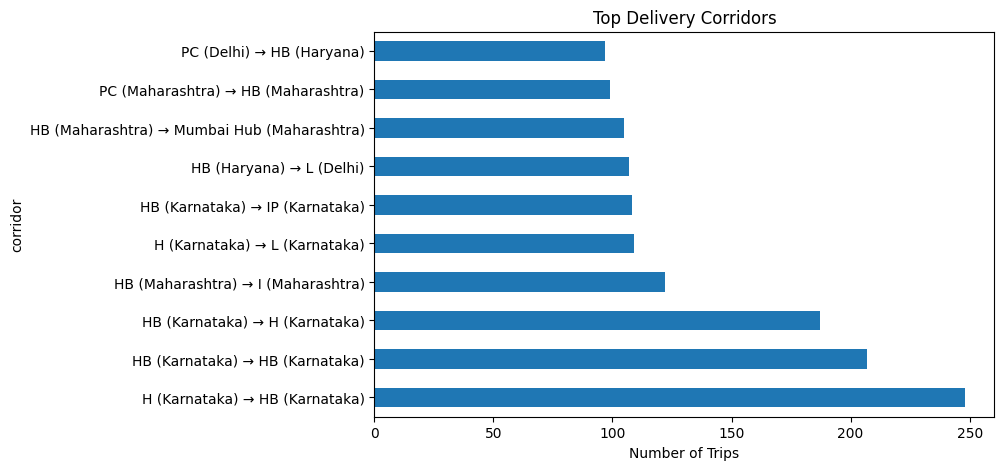

In [ ]:
trip_data['corridor'].value_counts().head(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top Delivery Corridors")
plt.xlabel("Number of Trips")

plt.show()

**Observation**:
Some corridors show significantly higher shipment movement,
indicating heavily utilized logistics routes.

Business Insight:

Busiest corridors may require:

- dedicated transportation planning
- route optimization
- additional vehicles
- better hub management

In [ ]:
#Average Distance by Corridor
trip_data.groupby('corridor')[
    'osrm_distance'
].mean().sort_values(
    ascending=False
).head(10)

,osrm_distance
corridor,
Hub (Jharkhand) → DC (Jharkhand),3.964473
D (Rajasthan) → I (Rajasthan),3.838817
H (Tamil Nadu) → DC (Tamil Nadu),3.731346
4 (Kerala) → H (Kerala),3.717085
2 (Maharashtra) → 2 (Maharashtra),3.714203
H (Haryana) → HB (Haryana),3.605609
I (Karnataka) → I (Karnataka),3.507520
3 (Maharashtra) → 2 (Maharashtra),3.397994
H (Haryana) → DC (Uttarakhand),3.395694


**Observation**:
Some delivery corridors involve significantly longer travel distances,
which can increase fuel costs and delivery time variability.

In [ ]:
#Average Time Taken by Corridor
trip_data.groupby('corridor')[
    'actual_time'
].mean().sort_values(
    ascending=False
).head(10)

,actual_time
corridor,
Hub (Jharkhand) → DC (Jharkhand),5.771303
1 (Arunachal Pradesh) → H (Assam),4.239890
D (Rajasthan) → I (Rajasthan),4.068512
D (Assam) → 1 (Nagaland),4.057526
D (Rajasthan) → 7 (Rajasthan),3.916909
2 (Tamil Nadu) → H (Karnataka),3.530211
D (Karnataka) → I (Karnataka),3.510436
HB (Haryana) → L (Uttar Pradesh),3.359382
I (Karnataka) → I (Karnataka),3.301707


**Observation**:
Certain corridors show very high average delivery times,
indicating possible traffic congestion or operational inefficiencies.

In [ ]:
#Average Delivery Time by Route Type
trip_data.groupby('route_type_FTL')[
    'actual_time'
].mean()

,actual_time
route_type_FTL,
False,-0.110771
True,0.501617


**Observation**:

FTL and Carting transportation modes show differences
in average delivery performance.

One transportation type may provide faster and more efficient deliveries.

####**Business Insight:**
Transportation mode optimization can help reduce delivery delays
and improve shipment efficiency.

In [ ]:
#Difference Between Actual and OSRM Time
trip_data['time_delay'] = (
    trip_data['actual_time'] -
    trip_data['osrm_time']
)

In [ ]:
#Average Delay
trip_data['time_delay'].mean()

np.float64(2.790932288714262e-17)

**Observation**:

Actual delivery times are generally higher than OSRM estimated times,
indicating real-world operational delays.

**Business Insight:**

Delivery delays may occur due to:
- traffic congestion
- route diversions
- weather conditions
- loading/unloading inefficiencies
- warehouse processing delays

###**Key Business Insights:**

1. Logistics demand is concentrated in a few high-volume states.

2. Certain delivery corridors handle a disproportionately high number of shipments.

3. Actual delivery times are consistently higher than OSRM estimated times.

4. Long-distance corridors contribute heavily to operational delays.

5. Segment-level delays significantly impact complete trip performance.

6. Transportation mode influences delivery efficiency and trip duration.

7. Outliers indicate occasional operational disruptions or abnormal shipment conditions.

##**10: Recommendations**

Based on the analysis and business insights obtained from the logistics dataset, the following actionable recommendations can help improve delivery efficiency and operational performance.

###**Business Recommendations**

**1. Improve High-Delay Corridors**

Some delivery corridors consistently show higher delivery times than expected.

**Recommendation:**


Monitor high-delay routes regularly


Use alternative routes during peak traffic hours


Increase operational support in congested corridors


**Expected Benefit:**


Faster deliveries


Reduced shipment delays


Better customer satisfaction

**2. Strengthen Operations in High-Demand States**

A few states contribute the majority of shipment volume.

**Recommendation**:


- Increase warehouse capacity in high-volume states


- Allocate more delivery vehicles and staff


- Improve hub-level coordination


**Expected Benefit**


Better handling of large shipment volumes


Reduced operational bottlenecks



**3. Optimize Transportation Mode Usage**

Different transportation types show different delivery performance.

**Recommendation:**


- Use Full Truck Load (FTL) more frequently for long-distance routes


- Use Carting efficiently for shorter and local deliveries


**Expected Benefit:**


Improved delivery speed


Better fuel and vehicle utilization



**4. Reduce Segment-Level Delays**

Segment-level delays significantly affect complete trip duration.

**Recommendation:**


- Improve coordination between hubs


- Reduce waiting time during package transfers


- Streamline loading and unloading operations


**Expected Benefit:**


Smoother shipment movement


Lower total delivery time



**5. Monitor Extreme Delivery Delays**

Outliers indicate occasional operational issues.

**Recommendation:**


- Create alerts for unusually delayed trips


- Investigate trips with abnormal delivery times


- Track repeated delay patterns


**Expected Benefit:**


- Faster issue resolution


- Improved operational reliability



**6. Improve Route Planning**

Actual delivery times are often higher than estimated times.

**Recommendation:**


- Continuously update routing plans using real traffic conditions


- Avoid frequently congested areas during peak hours


**Expected Benefit:**


More accurate delivery estimates


Reduced delivery delays



**7. Focus on Long-Distance Corridors**

Long-distance routes contribute heavily to delays and operational cost.

**Recommendation:**


- Use dedicated vehicles for long routes


- Plan better rest and fuel stops


- Improve scheduling for interstate deliveries


**Expected Benefit:**


- Better route efficiency


- Lower transportation cost



###**Final Conclusion**

The analysis identified major operational patterns, delivery delays,high-demand corridors, and transportation inefficiencies.By improving route planning, optimizing transportation modes,reducing segment delays, and strengthening operations in high-volume areas,the company can significantly improve delivery performanceand customer satisfaction.